# <center> Homework 114

In [1]:
from sklearn.datasets import load_sample_images
import tensorflow as tf
import matplotlib.pyplot as plt

2026-02-02 18:12:50.536583: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-02 18:12:51.878700: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-02 18:12:55.916993: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [2]:
images = load_sample_images()["images"]

In [3]:
images[0].shape

(427, 640, 3)

(np.float64(-0.5), np.float64(639.5), np.float64(426.5), np.float64(-0.5))

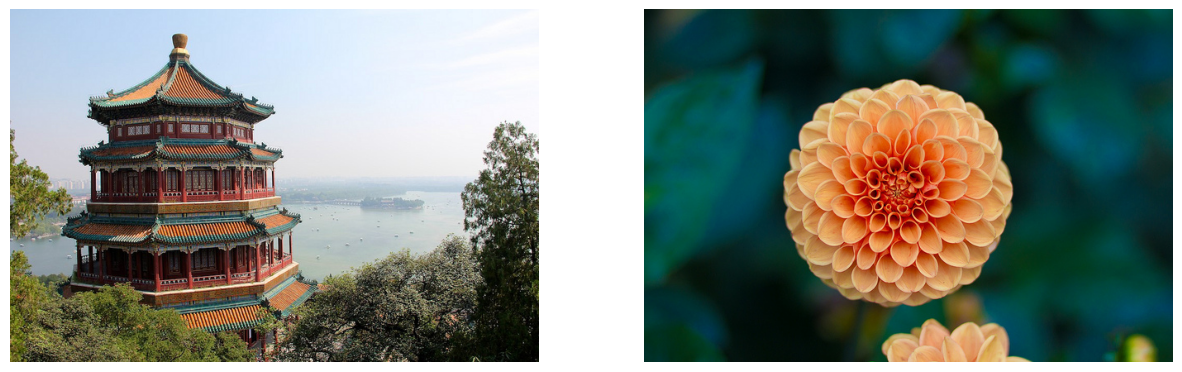

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(15, 8))

ax[0].imshow(images[0])
ax[1].imshow(images[1])
ax[0].axis('off')
ax[1].axis('off')

In [7]:
img = images[0]
img = tf.reshape(img, [1, *img.shape])
img.shape

TensorShape([1, 427, 640, 3])

(1, 213, 320, 3)


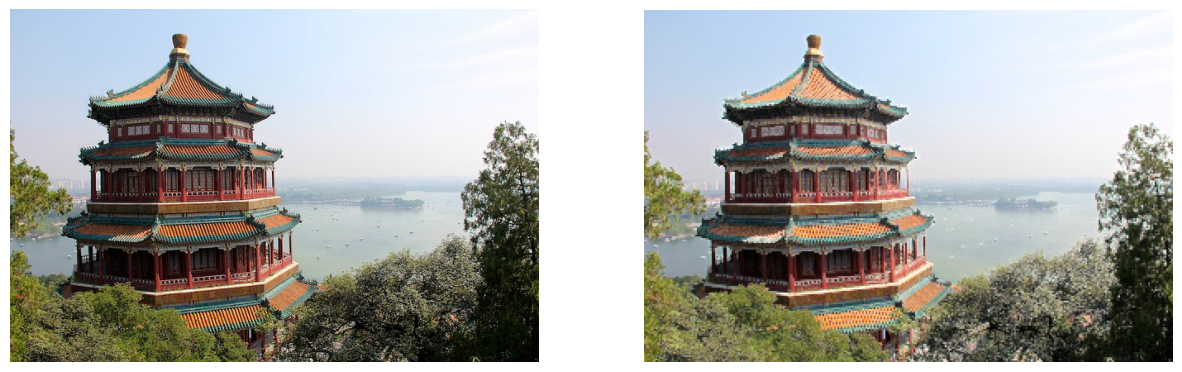

In [ ]:
from tf_model import Input, MaxPool2D

maxpool = MaxPool2D()(Input(img.shape[1:]))
shrink_img = maxpool.call(img)

fig, ax = plt.subplots(1, 2, figsize=(15, 8))

ax[0].imshow(img[0]) 
ax[1].imshow(shrink_img[0])
ax[0].axis('off')
ax[1].axis('off')

print(shrink_img.shape)

In [17]:
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

2026-01-23 14:53:55.607360: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [18]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7)
fmaps = conv_layer(images)

## Task 1

In [20]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [23]:
X_train = X_train.reshape(*X_train.shape, 1)
X_valid = X_valid.reshape(*X_valid.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

In [35]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),
    tf.keras.layers.Rescaling(scale=1 / 255),

    tf.keras.layers.Conv2D(filters=32, kernel_size=4, activation='relu'),
    tf.keras.layers.Conv2D(filters=64, kernel_size=5, activation='relu'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [41]:
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 25, 25, 32)     │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 64)     │        51,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 28224)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,612,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,665,898 (13.98 MB)

 Trainable params: 3,665,898 (13.98 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.fit(X_train, y_train, epochs=20, validation_data=(X_valid, y_valid))


Epoch 1/20


2026-01-23 16:04:24.225541: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 43120000 exceeds 10% of free system memory.


 152/1719 ━━━━━━━━━━━━━━━━━━━━ 4:13 162ms/step - accuracy: 0.6424 - loss: 0.9924

KeyboardInterrupt: 

## Test

In [37]:
from importlib import reload
import tf_model
reload(tf_model)
from tf_model import Model, Input, Dense, SGD, Adam, Normalization, Mean, Conv2D, Sequential, Flatten, MaxPool2D, Dropout
import tensorflow as tf

fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:10_000], y_train_full[:10_000]
X_valid, y_valid = X_train_full[-2000:], y_train_full[-2000:]

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

X_train = X_train.reshape(*X_train.shape, 1)
X_valid = X_valid.reshape(*X_valid.shape, 1)
X_test = X_test.reshape(*X_test.shape, 1)

In [26]:
class CustomConv2D(tf.keras.Layer):
    def __init__(self, filters, kernel_size, strides=(1, 1), padding='valid', 
                 activation=None, kernel_initializer='glorot_uniform', **kwargs):
        super().__init__(**kwargs)
        self.filters = filters
        self.padding = padding 
        self.activation = tf.keras.activations.get(activation)
        self.kernel_initializer = tf.keras.initializers.get(kernel_initializer)
        
        if not isinstance(kernel_size, tuple):
            kernel_size = (kernel_size, kernel_size)

        assert len(kernel_size) == 2, 'Invalid kernel_size'
        self.kernel_size = kernel_size

        if not isinstance(strides, tuple):
            strides = (strides, strides)
            
        assert len(strides) == 2, 'Invalid strides'
        self.strides = strides

    def _calc_output_shape(self, input):
        match self.padding:
            case 'valid':
                H_out = tf.cast(tf.math.floor((input[0] - self.kernel_size[0]) / self.strides[0]) + 1, tf.int32)
                W_out = tf.cast(tf.math.floor((input[1] - self.kernel_size[1]) / self.strides[1]) + 1, tf.int32)
            case 'same':
                H_out = tf.cast(tf.math.ceil(input[0] / self.strides[0]), tf.int32)
                W_out = tf.cast(tf.math.ceil(input[1] / self.strides[1]), tf.int32)
            case _:
                raise ValueError(f'Invalid padding: {self.padding}; expects: valid/same')
            
        self.output_shape = [H_out, W_out, self.filters]

    def build(self, input_shape):
        C_in = input_shape[-1]

        self.kernel = self.add_weight(name="kernel",
                                    shape=(*self.kernel_size, C_in, self.filters),
                                    initializer=self.kernel_initializer)

        self.bias = self.add_weight(name="bias",
                                shape=(self.filters,),
                                initializer="zeros")
        
        self._calc_output_shape(input_shape[1:])

    @tf.function
    def _calc(self, X):
        H_out, W_out, C_out = self.output_shape
        B_in, C_in = tf.shape(X)[0], tf.shape(X)[-1]

        patches = tf.image.extract_patches(
            images=X,
            sizes=[1, *self.kernel_size, 1],    
            strides=[1, *self.strides, 1],        
            rates=[1, 1, 1, 1],                                      
            padding=self.padding.upper()               
        )

        kernel_prod  = tf.reduce_prod(self.kernel_size)
        patches_flat = tf.reshape(patches, [B_in * H_out * W_out, kernel_prod * C_in])
        weights_flat = tf.reshape(self.kernel, [kernel_prod * C_in, C_out])
        out_flat     = tf.matmul(patches_flat, weights_flat) + self.bias
        out          = tf.reshape(out_flat, [B_in, H_out, W_out, C_out])
        return self.activation(out)

    def call(self, X, *_):
        if len(X.shape) < 3:
            raise ValueError('Conv2D except 3D inputs')
        
        return self._calc(X)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "filters": self.filters,
            "kernel_size": self.kernel_size,
            "strides": self.strides,
            "padding": self.padding,
            "output":  self.output_shape,
            "activation": tf.keras.activations.serialize(self.activation),
            "kernel_initializer": tf.keras.initializers.serialize(self.kernel_initializer),
        })
        return config

In [33]:
class CustomMaxPool2D(tf.keras.Layer):
    def __init__(self, pool_size=(2, 2), strides=None, padding='valid', **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size
        self.padding = padding

        if strides is None:
            strides = pool_size

        self.strides = strides
        self.kernel_size = pool_size

    def _calc_output_shape(self, input):
        match self.padding:
            case 'valid':
                H_out = tf.cast(tf.math.floor((input[0] - self.kernel_size[0]) / self.strides[0]) + 1, tf.int32)
                W_out = tf.cast(tf.math.floor((input[1] - self.kernel_size[1]) / self.strides[1]) + 1, tf.int32)
            case 'same':
                H_out = tf.cast(tf.math.ceil(input[0] / self.strides[0]), tf.int32)
                W_out = tf.cast(tf.math.ceil(input[1] / self.strides[1]), tf.int32)
            case _:
                raise ValueError(f'Invalid padding: {self.padding}; expects: valid/same')
            
        self.output_shape = [H_out, W_out, input[-1]]

    def build(self, input_shape):
        self._calc_output_shape(input_shape[1:])

    @tf.function
    def _calc(self, X):
        H_out, W_out, C_out = self.output_shape
        B_in, C_in = tf.shape(X)[0], tf.shape(X)[-1]

        patches = tf.image.extract_patches(
            images=X,
            sizes=[1, *self.kernel_size, 1],    
            strides=[1, *self.strides, 1],        
            rates=[1, 1, 1, 1],                                      
            padding=self.padding.upper()               
        )

        kernel_prod  = tf.reduce_prod(self.kernel_size)
        patches_reshaped = tf.reshape(patches, [B_in, H_out, W_out, kernel_prod, C_in])
        return tf.reduce_max(patches_reshaped, axis=3)

    def call(self, X, *_):
        if len(X.shape) < 3:
            raise ValueError('Conv2D except 3D inputs')
        
        return self._calc(X)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            "kernel_size": self.kernel_size,
            "strides": self.strides,
            "padding": self.padding,
            "output":  self.output_shape,
        })
        return config

In [ ]:
cnn = tf.keras.models.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),

    # CustomConv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters=32, kernel_size=3, activation='relu', kernel_initializer='he_normal'),
    CustomMaxPool2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(10, activation='softmax')
])

cnn.compile(loss='sparse_categorical_crossentropy', 
            optimizer='adam', metrics=['accuracy'])

cnn.fit(X_train, y_train, epochs=10, batch_size=16,
        validation_data=(X_valid, y_valid))

In [38]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 28s 0us/step


In [45]:
X_train_full, y_train_full = x_train, y_train

In [46]:
X_train, y_train = X_train_full[:10_000], y_train_full[:10_000]
X_valid, y_valid = X_train_full[-2000:], y_train_full[-2000:]

X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [66]:
import tf_model
reload(tf_model)

from tf_model import (Model, Input, Dense, SGD, Adam, Normalization, 
                      Mean, Conv2D, Sequential, Flatten, MaxPool2D, Dropout,
                      Lambda)

from functools import partial

In [69]:
LRN = partial(tf.nn.local_response_normalization, 
              depth_radius=5,
              bias=2,
              alpha=0.0001,
              beta=0.75
            )

alexnet = Sequential([
    Input(X_train.shape[1:], name='In'),

    Conv2D(96, kernel_size=5, strides=1, activation='relu', kernel_initializer='he_normal', name='C1'),
    Lambda(LRN),
    MaxPool2D(pool_size=3, strides=2, name='S2'),

    Conv2D(256, kernel_size=5, padding='same', activation='relu', kernel_initializer='he_normal', name='C3'),
    Lambda(LRN),
    MaxPool2D(pool_size=3, strides=2, name='S4'),

    Conv2D(384, kernel_size=3, activation='relu', padding='same', kernel_initializer='he_normal', name='C5'),
    Conv2D(384, kernel_size=3, activation='relu', padding='same', kernel_initializer='he_normal', name='C6'),
    Conv2D(256, kernel_size=3, activation='relu', padding='same', kernel_initializer='he_normal', name='C7'),
    MaxPool2D(pool_size=3, strides=2, name='S8'),

    Flatten(),

    Dense(4096, activation='relu', kernel_initializer='he_normal', name='F9'),
    Dropout(0.5),

    Dense(4096, activation='relu', kernel_initializer='he_normal', name='F10'),
    Dropout(0.5),

    Dense(10, activation='softmax', name='out')
])

In [70]:
alexnet.compile('adam', 'sparse_categorical_crossentropy', ['accuracy'])

alexnet.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10


  0%|          | 0/313 [00:00<?, ?it/s]

(32, 28, 28, 96)
(32, 28, 28, 96)
(32, 13, 13, 256)
(32, 13, 13, 256)
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, metric, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report th

2026-01-28 16:14:30.333404: I external/local_xla/xla/service/service.cc:163] XLA service 0x725a8c1abcf0 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
2026-01-28 16:14:30.333436: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Host, Default Version
I0000 00:00:1769609670.915655   31526 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2026-01-28 16:14:31.770816: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:62] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. random_uniform/RandomUniform
2026-01-28 16:14:32.278188: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
  6%|▋         | 20/313 [00:48<11:49,  2.42s/it] 


KeyboardInterrupt: 

In [125]:
from functools import partial

class InceptionModules(tf.keras.Layer):
    def __init__(self, n_filters, **kwargs):
        super().__init__(**kwargs)

        '''
                        Concatenate

        Conv2D 00 | Conv2D 01 | Conv2D 02 | Conv2D  03  
        None      | Conv2D 11 | Conv2D 12 | MaxPool 03  

                           Input
        '''

        default_conv = partial(tf.keras.layers.Conv2D, 
                               padding='same',
                               activation='relu',
                               kernel_initializer='he_normal',
                               kernel_size=1)
        
        self.conv00 = default_conv(n_filters[0][0])

        self.conv01 = default_conv(n_filters[0][1], kernel_size=3)
        self.conv11 = default_conv(n_filters[1][1])

        self.conv02 = default_conv(n_filters[0][2], kernel_size=5)
        self.conv12 = default_conv(n_filters[1][2])

        self.conv03 = default_conv(n_filters[0][3])
        self.maxpool13 = tf.keras.layers.MaxPool2D(pool_size=3, 
                                                 strides=1, 
                                                 padding='same')
        
        self.concat = tf.keras.layers.Concatenate(axis=-1) 

    def call(self, X, *_):
        out1 = self.conv00(X)

        out2 = self.conv11(X)
        out2 = self.conv01(out2)

        out3 = self.conv12(X)
        out3 = self.conv02(out3)

        out4 = self.maxpool13(X)
        out4 = self.conv03(out4)

        return self.concat([out1, out2, out3, out4])
        

In [74]:
LRN = partial(tf.nn.local_response_normalization, 
              depth_radius=5,
              bias=2,
              alpha=0.0001,
              beta=0.75
            )

default_conv = partial(tf.keras.layers.Conv2D, 
                        padding='same',
                        activation='relu',
                        kernel_initializer='he_normal',
                        kernel_size=1)

default_maxpool = partial(tf.keras.layers.MaxPool2D, 
                          pool_size=3, 
                          strides=2, 
                          padding='same')

googlenet = tf.keras.Sequential([
    tf.keras.layers.Input(X_train.shape[1:]),

    default_conv(64, kernel_size=7, strides=1),
    default_maxpool(),
    tf.keras.layers.Lambda(LRN),

    default_conv(64),
    default_conv(192, kernel_size=3),
    tf.keras.layers.Lambda(LRN),
    default_maxpool(),

    InceptionModules([
        [64  , 128, 32, 32],
        [None, 96 , 12, None],
    ]),

    InceptionModules([
        [128 , 192, 96, 64],
        [None, 128, 32, None],
    ]),

    default_maxpool(),

    InceptionModules([
        [192 , 208, 48, 64],
        [None, 96 , 16, None],
    ]),

    InceptionModules([
        [160 , 224, 64, 64],
        [None, 112, 24, None],
    ]),

    InceptionModules([
        [128 , 256, 64, 64],
        [None, 112, 24, None],
    ]),

    InceptionModules([
        [112 , 288, 64, 64],
        [None, 144, 32, None],
    ]),

    InceptionModules([
        [256 , 320, 128, 128],
        [None, 160, 32, None],
    ]),

    default_maxpool(),

    InceptionModules([
        [256 , 320, 128, 128],
        [None, 160, 32, None],
    ]),

    InceptionModules([
        [384 , 384, 128, 128],
        [None, 192, 48 , None],
    ]),

    tf.keras.layers.GlobalAvgPool2D(),
    tf.keras.layers.Dropout(0.4),
    tf.keras.layers.Dense(10, activation='softmax')
])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/layer.py:1505: UserWarning: Layer 'inception_modules' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: ''InceptionModules.call() got an unexpected keyword argument '_'''
  warnings.warn(
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'inception_modules', however the layer does 

In [75]:
googlenet.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

googlenet.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10
 60/313 ━━━━━━━━━━━━━━━━━━━━ 5:05 1s/step - accuracy: 0.0977 - loss: 2.3271

KeyboardInterrupt: 

In [130]:
import tf_model
reload(tf_model)

from tf_model import (Model, Input, Dense, SGD, Adam, Normalization, 
                      Mean, Conv2D, Sequential, Flatten, MaxPool2D, Dropout,
                      Lambda, GlobalAvgPool2D, InceptionModules)

from functools import partial

In [131]:
LRN = partial(tf.nn.local_response_normalization, 
              depth_radius=5,
              bias=2,
              alpha=0.0001,
              beta=0.75
            )

default_conv = partial(Conv2D, 
                        padding='same',
                        activation='relu',
                        kernel_initializer='he_normal',
                        kernel_size=1)

default_maxpool = partial(MaxPool2D, 
                          pool_size=3, 
                          strides=2, 
                          padding='same')

googlenet = Sequential([
    Input(X_train.shape[1:]),

    default_conv(64, kernel_size=7, strides=1),
    # default_maxpool(),
    Lambda(LRN),

    default_conv(64),
    default_conv(192, kernel_size=3),
    Lambda(LRN),
    default_maxpool(),

    InceptionModules([
        [64  , 128, 32, 32],
        [None, 96 , 12, None],
    ]),

    InceptionModules([
        [128 , 192, 96, 64],
        [None, 128, 32, None],
    ]),

    default_maxpool(),

    InceptionModules([
        [192 , 208, 48, 64],
        [None, 96 , 16, None],
    ]),

    InceptionModules([
        [160 , 224, 64, 64],
        [None, 112, 24, None],
    ]),

    # InceptionModules([
    #     [128 , 256, 64, 64],
    #     [None, 112, 24, None],
    # ]),

    # InceptionModules([
    #     [112 , 288, 64, 64],
    #     [None, 144, 32, None],
    # ]),

    # InceptionModules([
    #     [256 , 320, 128, 128],
    #     [None, 160, 32, None],
    # ]),

    default_maxpool(),

    InceptionModules([
        [256 , 320, 128, 128],
        [None, 160, 32, None],
    ]),

    # InceptionModules([
    #     [384 , 384, 128, 128],
    #     [None, 192, 48 , None],
    # ]),

    GlobalAvgPool2D(),
    Dropout(0.4),
    Dense(10, activation='softmax')
])

In [132]:
googlenet.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

googlenet.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))

Epoch 1/10


  0%|          | 0/313 [00:00<?, ?it/s]

Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 (on Linux, `export AUTOGRAPH_VERBOSITY=10`) and attach the full output.
Cause: name node, self, outside of any statement?
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert
Please report this to the TensorFlow team. When filing the bug, set the verbosity to 10 

  2%|▏         | 7/313 [01:22<59:47, 11.72s/it]  


KeyboardInterrupt: 

In [129]:
LRN = partial(tf.nn.local_response_normalization, 
              depth_radius=5,
              bias=2,
              alpha=0.0001,
              beta=0.75
            )

default_conv = partial(tf.keras.layers.Conv2D, 
                        padding='same',
                        activation='relu',
                        kernel_initializer='he_normal',
                        kernel_size=1)

default_maxpool = partial(tf.keras.layers.MaxPool2D, 
                          pool_size=3, 
                          strides=2, 
                          padding='same')



inp = tf.keras.layers.Input(X_train.shape[1:])

conv1 = default_conv(64, kernel_size=7, strides=1)(inp)
maxpool1 = default_maxpool()(conv1)
lrn1 = tf.keras.layers.Lambda(LRN)(maxpool1)

conv2 = default_conv(64)(lrn1)
conv3 = default_conv(192, kernel_size=3)(conv2)
lrn2 = tf.keras.layers.Lambda(LRN)(conv3)
maxpool2 = default_maxpool()(lrn2)

inception1 = InceptionModules([
    [64  , 128, 32, 32],
    [None, 96 , 12, None],
])(maxpool2)

inception2 = InceptionModules([
    [128 , 192, 96, 64],
    [None, 128, 32, None],
])(inception1)

maxpool3 = default_maxpool()(inception2)

inception3 = InceptionModules([
    [192 , 208, 48, 64],
    [None, 96 , 16, None],
])(maxpool3)

# ------------ AUX 1 ------------
# average pooling layer, one convolutional layer, 
# two fully connected layers, and a softmax
# activation layer.

aux1_pool = tf.keras.layers.AvgPool2D(pool_size=3, strides=1)(inception3)
aux1_conv = default_conv(128)(aux1_pool)

aux1_flatten = tf.keras.layers.Flatten()(aux1_conv)

aux1_dense1 = tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal')(aux1_flatten)
aux1_dense2 = tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal')(aux1_dense1)
aux1_out    = tf.keras.layers.Dense(10, activation='softmax', name='aux1')(aux1_dense2)

# -------------------------------

inception4 = InceptionModules([
    [160 , 224, 64, 64],
    [None, 112, 24, None],
])(inception3)

inception5 = InceptionModules([
    [128 , 256, 64, 64],
    [None, 112, 24, None],
])(inception4)

inception6 = InceptionModules([
    [112 , 288, 64, 64],
    [None, 144, 32, None],
])(inception5)

# ------------ AUX 2 ------------

aux2_pool = tf.keras.layers.AvgPool2D(pool_size=3, strides=1)(inception6)
aux2_conv = default_conv(128)(aux2_pool)

aux2_flatten = tf.keras.layers.Flatten()(aux2_conv)

aux2_dense1 = tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal')(aux2_flatten)
aux2_dense2 = tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal')(aux2_dense1)
aux2_out    = tf.keras.layers.Dense(10, activation='softmax', name='aux2')(aux2_dense2)

# -------------------------------

inception7 = InceptionModules([
    [256 , 320, 128, 128],
    [None, 160, 32, None],
])(inception6)

maxpool4 = default_maxpool()(inception7)

inception8 = InceptionModules([
    [256 , 320, 128, 128],
    [None, 160, 32, None],
])(maxpool4)

inception9 = InceptionModules([
    [384 , 384, 128, 128],
    [None, 192, 48 , None],
])(inception8)

glob_avg_pool = tf.keras.layers.GlobalAvgPool2D()(inception9)
drop = tf.keras.layers.Dropout(0.4)(glob_avg_pool)
main_out = tf.keras.layers.Dense(10, activation='softmax', name='main')(drop)

googlenet_func_api = tf.keras.Model(inputs=[inp], outputs=[main_out, aux1_out, aux2_out])

/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/layer.py:1505: UserWarning: Layer 'inception_modules_28' looks like it has unbuilt state, but Keras is not able to trace the layer `call()` in order to build it automatically. Possible causes:
1. The `call()` method of your layer may be crashing. Try to `__call__()` the layer eagerly on some test input first to see if it works. E.g. `x = np.random.random((3, 4)); y = layer(x)`
2. If the `call()` method is correct, then you may need to implement the `def build(self, input_shape)` method on your layer. It should create all variables used by the layer (e.g. by calling `layer.build()` on all its children layers).
Exception encountered: ''InceptionModules.call() got an unexpected keyword argument '_'''
  warnings.warn(
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'inception_modules_28', however the layer

In [ ]:
googlenet_func_api.compile(loss={
    'main': 'sparse_categorical_crossentropy',
    'aux1': 'sparse_categorical_crossentropy',
    'aux2': 'sparse_categorical_crossentropy',
    }, loss_weights={
        'main': 1.0,
        'aux1': 0.3,
        'aux2': 0.3,
    }, metrics={
        'main': 'accuracy',
        'aux1': 'accuracy',
        'aux2': 'accuracy',
    }, optimizer='adam')


googlenet_func_api.fit(X_train, (y_train, y_train, y_train), epochs=10,
                       validation_data=(X_valid, (y_valid, y_valid, y_valid)))

## Task 3
да се имплементират архитектурата на Inception-v4

- Input 299 x 299
- Stem
- 4 x Inception A
- Reduction A
- 7 x Inception B
- Reduction B
- 3 x Inception C
- Average pooling
- Dropout 20%
- Softmax

In [136]:
# ================== Stem ==================

conv2d = partial(tf.keras.layers.Conv2D, 
                 kernel_size=3, 
                 padding='same',
                 kernel_initializer="he_normal",
                 use_bias=False)

maxpool = partial(tf.keras.layers.MaxPool2D,
                  pool_size=3,
                  padding='same',
                  strides=2)


inp = tf.keras.layers.Input([299, 299, 3])
x = conv2d(32, strides=2, padding='valid')(inp)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)

x = conv2d(32, padding='valid')(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)

x = conv2d(64)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation("relu")(x)

a = maxpool(padding='valid')(x)

b = conv2d(96, strides=2, padding='valid')(x)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)

x = tf.keras.layers.Concatenate()([a, b])

a = conv2d(64, kernel_size=1)(x)
a = tf.keras.layers.BatchNormalization()(a)
a = tf.keras.layers.Activation("relu")(a)

a = conv2d(96, padding='valid')(a)
a = tf.keras.layers.BatchNormalization()(a)
a = tf.keras.layers.Activation("relu")(a)


b = conv2d(64, kernel_size=1)(x)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)

b = conv2d(64, kernel_size=(7, 1))(b)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)

b = conv2d(64, kernel_size=(1, 7))(b)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)

b = conv2d(96, padding='valid')(b)
b = tf.keras.layers.BatchNormalization()(b)
b = tf.keras.layers.Activation("relu")(b)


x = tf.keras.layers.Concatenate()([a, b])

a = conv2d(192, strides=2, padding='valid')(x)
a = tf.keras.layers.BatchNormalization()(a)
a = tf.keras.layers.Activation("relu")(a)

b = maxpool(padding='valid')(x)


out = tf.keras.layers.Concatenate()([a, b])

stem = tf.keras.Model(inputs=[inp], outputs=[out])

In [137]:
class InceptionA(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        self.branch1 = tf.keras.Sequential([
            tf.keras.layers.AvgPool2D(pool_size=3, strides=1, padding='same'),

            conv2d(96, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch2 = tf.keras.Sequential([
            conv2d(96, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch3 = tf.keras.Sequential([
            conv2d(64, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(96),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch4 = tf.keras.Sequential([
            conv2d(64, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(96),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(96),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.concat = tf.keras.layers.Concatenate()

    def call(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)
        out4 = self.branch4(x)
        return self.concat([out1, out2, out3, out4])

In [138]:
class InceptionB(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        self.branch1 = tf.keras.Sequential([
            tf.keras.layers.AvgPool2D(pool_size=3, strides=1, padding='same'),

            conv2d(128, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch2 = tf.keras.Sequential([
            conv2d(384, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch3 = tf.keras.Sequential([
            conv2d(192, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(224, kernel_size=(1, 7)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(256, kernel_size=(1, 7)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch4 = tf.keras.Sequential([
            conv2d(192, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(192, kernel_size=(1, 7)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(224, kernel_size=(7, 1)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(224, kernel_size=(1, 7)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(256, kernel_size=(7, 1)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
        ])
        
        self.concat = tf.keras.layers.Concatenate()

    def call(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)
        out4 = self.branch4(x)
        return self.concat([out1, out2, out3, out4])

In [ ]:
class InceptionC(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        self.branch1 = tf.keras.Sequential([
            tf.keras.layers.AvgPool2D(pool_size=3, strides=1, padding='same'),

            conv2d(256, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch2 = tf.keras.Sequential([
            conv2d(256, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch3 = tf.keras.Sequential([
            conv2d(384, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
        ])

        self.out3 = tf.keras.Sequential([
            conv2d(256, kernel_size=(1, 3)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
        ])

        self.out4 = tf.keras.Sequential([
            conv2d(256, kernel_size=(3, 1)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
        ])
        
        self.branch4 = tf.keras.Sequential([
            conv2d(384, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(448, kernel_size=(1, 3)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(512, kernel_size=(3, 1)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
        ])

        self.out5 = tf.keras.Sequential([
            conv2d(256, kernel_size=(3, 1)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
        ])

        self.out6 = tf.keras.Sequential([
            conv2d(256, kernel_size=(1, 3)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),
        ])

        self.concat = tf.keras.layers.Concatenate()

    def call(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)

        branch3 = self.branch3(x)
        out3 = self.out3(branch3)
        out4 = self.out4(branch3)

        branch4 = self.branch4(x)
        out5 = self.out5(branch4)
        out6 = self.out6(branch4)

        return self.concat([out1, out2, out3, out4, out5, out6])

In [ ]:
class ReductionA(tf.keras.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        self.branch1 = maxpool(padding='valid')
        
        self.branch2 = tf.keras.Sequential([
            conv2d(384, strides=2, padding='valid'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch3 = tf.keras.Sequential([
            conv2d(192, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(224),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(256, strides=2),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.concat = tf.keras.layers.Concatenate()

    def call(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)

        return self.concat([out1, out2, out3])

In [ ]:
class ReductionB(tf.keras.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        
        self.branch1 = maxpool(padding='valid')
        
        self.branch2 = tf.keras.Sequential([
            conv2d(192, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(192, strides=2, padding='valid'),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.branch3 = tf.keras.Sequential([
            conv2d(256, kernel_size=1),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(256, kernel_size=(1, 7)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(320, kernel_size=(7, 1)),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            conv2d(320, strides=2),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu')
        ])
        
        self.concat = tf.keras.layers.Concatenate()

    def call(self, x):
        out1 = self.branch1(x)
        out2 = self.branch2(x)
        out3 = self.branch3(x)

        return self.concat([out1, out2, out3])

# HW 119


In [1]:
import tensorflow as tf
from functools import partial

2026-01-30 14:29:26.281533: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-30 14:29:27.398896: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-30 14:29:33.018549: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/zdravko/Machine_Learning_Intern/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [5]:
class DepthwiseConv2D(tf.keras.layers.Layer):
    def __init__(self, kernel_size, strides=(1, 1), padding='valid', 
                 depth_multiplier=1, activation=None, use_bias=True, 
                 depthwise_initializer='glorot_uniform', 
                 bias_initializer='zeros', **kwargs):
        
        super().__init__(**kwargs)

        if not isinstance(kernel_size, (list, tuple)):
            kernel_size = (kernel_size, kernel_size)

        if not isinstance(strides, (list, tuple)):
            strides = (strides, strides)

        self.kernel_size = kernel_size
        self.strides = strides
        self.padding = padding
        self.depth_multiplier = depth_multiplier
        self.activation = tf.keras.activations.get(activation)
        self.use_bias = use_bias
        self.depthwise_initializer = depthwise_initializer
        self.bias_initializer = bias_initializer

    def build(self, input_shape): 
        self.kernel = self.add_weight(shape=[*self.kernel_size, input_shape[-1], self.depth_multiplier], 
                                       initializer=self.depthwise_initializer,
                                       dtype=tf.float32)
        
        if self.use_bias:
            self.bias = self.add_weight(shape=[input_shape[-1] * self.depth_multiplier],
                                        initializer=self.bias_initializer,
                                        dtype=tf.float32)

    def call(self, input):
        conv = tf.nn.depthwise_conv2d(
                input,
                self.kernel,
                strides=[1, *self.strides, 1],
                padding=self.padding.upper()
        )

        if self.use_bias:
            conv = tf.nn.bias_add(conv, self.bias)

        if self.activation is not None:
            conv = self.activation(conv) 

        return conv
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'kernel_size':           self.kernel_size,
            'strides':               self.strides,
            'padding':               self.padding,
            'depth_multiplier':      self.depth_multiplier,
            'activation':            tf.keras.activations.serialize(self.activation),
            'use_bias':              self.use_bias,
            'depthwise_initializer': self.depthwise_initializer,
            'bias_initializer':      self.bias_initializer,
        })
        return config

    
class SeparableConv2D(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size, strides=(1, 1), 
                 padding='valid', depth_multiplier=1, activation=None,
                 depthwise_initializer='glorot_uniform', 
                 pointwise_initializer='glorot_uniform', 
                 bias_initializer='zeros', **kwargs):
        
        super().__init__(**kwargs)

        self.pointwise = tf.keras.layers.Conv2D(filters, 
                                                kernel_size=1,
                                                strides=1,
                                                padding='same',
                                                activation=None,
                                                kernel_initializer=pointwise_initializer,
                                                bias_initializer=bias_initializer)
        
        self.depthwise = DepthwiseConv2D(kernel_size=kernel_size,
                                         strides=strides,
                                         padding=padding,
                                         depth_multiplier=depth_multiplier,
                                         depthwise_initializer=depthwise_initializer,
                                         use_bias=False,
                                         )
        
        self.activation = tf.keras.activations.get(activation)
        
    def call(self, input):
        x = self.pointwise(input)

        if self.activation is not None:
            x = self.activation(x)

        return self.depthwise(x)
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'activation': tf.keras.activations.serialize(self.activation)
        })



In [7]:
conv2d = partial(tf.keras.layers.Conv2D, 
                 kernel_size=3, 
                 padding='same',
                 kernel_initializer="he_normal",
                 use_bias=False)

maxpool = partial(tf.keras.layers.MaxPool2D,
                  pool_size=3,
                  padding='same',
                  strides=2)

separable = partial(SeparableConv2D, 
                    kernel_size=3, 
                    padding='same',
                    depthwise_initializer='he_normal', 
                    pointwise_initializer='glorot_uniform')

inp = tf.keras.Input([299, 299, 3])

x = conv2d(32, strides=2)(inp)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = conv2d(64)(x)
x = tf.keras.layers.BatchNormalization()(x)
skip = tf.keras.layers.Activation('relu')(x)

x = separable(128)(skip)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = separable(128)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = maxpool()(x)

skip = conv2d(128, kernel_size=1, strides=2)(skip)
skip = tf.keras.layers.BatchNormalization()(skip)
skip = tf.keras.layers.Add()([skip, x])

x = tf.keras.layers.Activation('relu')(skip)
x = separable(256)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = separable(256)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = maxpool()(x)

skip = conv2d(256, kernel_size=1, strides=2)(skip)
skip = tf.keras.layers.BatchNormalization()(skip)
skip = tf.keras.layers.Add()([skip, x])

x = tf.keras.layers.Activation('relu')(skip)
x = separable(728)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = separable(728)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = maxpool()(x)

skip = conv2d(728, kernel_size=1, strides=2)(skip)
skip = tf.keras.layers.BatchNormalization()(skip)
out = tf.keras.layers.Add()([skip, x])

entry_flow = tf.keras.Model(inputs=[inp], outputs=[out])

In [8]:
class MiddleFlow(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

        self.flow = tf.keras.Sequential([
            tf.keras.layers.Activation('relu'),
            
            separable(728),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            separable(728),
            tf.keras.layers.BatchNormalization(),
            tf.keras.layers.Activation('relu'),

            separable(728),
            tf.keras.layers.BatchNormalization(),
        ])

        self.add = tf.keras.layers.Add()

    def call(self, input):
        x = self.flow(input)
        return self.add([input, x])

In [ ]:
inp = tf.keras.layers.Input([19, 19, 728])

x = tf.keras.layers.Activation('relu')(inp)
x = separable(728)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = separable(1024)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = maxpool()(x)

skip = conv2d(1024, kernel_size=1, strides=2)(inp)
skip = tf.keras.layers.BatchNormalization()(skip)
x = tf.keras.layers.Add()([skip, x])

x = separable(1536)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = separable(2048)(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Activation('relu')(x)

x = tf.keras.layers.GlobalAvgPool2D()(x)

out = tf.keras.layers.Dense(10, activation='softmax')(x)

exit_flow = tf.keras.Model(inputs=[inp], outputs=[out])

In [ ]:
inp = tf.keras.layers.Input(X_train.shape[1:])
resize = tf.keras.layers.Resizing(299, 299)(inp)

x = entry_flow(resize)

for _ in range(8):
    x = MiddleFlow()(x)

out = exit_flow(x)

xception = tf.keras.Model(inputs=inp, outputs=out)

se net

In [9]:

class InceptionModule(tf.keras.Layer):
    def __init__(self, n_filters, **kwargs):
        super().__init__(**kwargs)
        from functools import partial

        '''
                        Concatenate

        Conv2D 00 | Conv2D 01 | Conv2D 02 | Conv2D  03  
        None      | Conv2D 11 | Conv2D 12 | MaxPool 03  

                           Input
        '''

        default_conv = partial(tf.keras.layers.Conv2D, 
                               padding='same',
                               activation='relu',
                               kernel_initializer='he_normal',
                               kernel_size=1)
        
        self.conv00 = default_conv(n_filters[0][0])

        self.conv01 = default_conv(n_filters[0][1], kernel_size=3)
        self.conv11 = default_conv(n_filters[1][1])

        self.conv02 = default_conv(n_filters[0][2], kernel_size=5)
        self.conv12 = default_conv(n_filters[1][2])

        self.conv03 = default_conv(n_filters[0][3])
        self.maxpool13 = tf.keras.layers.MaxPool2D(pool_size=3, 
                                                 strides=1, 
                                                 padding='same')
        
        self.concat = tf.keras.layers.Concatenate(axis=-1) 

    def call(self, X, *_):
        out1 = self.conv00(X)

        out2 = self.conv11(X)
        out2 = self.conv01(out2)

        out3 = self.conv12(X)
        out3 = self.conv02(out3)

        out4 = self.maxpool13(X)
        out4 = self.conv03(out4)

        return self.concat([out1, out2, out3, out4])
        



class SEBlock(tf.keras.layers.Layer):
    def __init__(self, reduction_factor=16, **kwargs):
        super().__init__(**kwargs)
        self.reduction_factor = reduction_factor
        self.global_pool = tf.keras.layers.GlobalAveragePooling2D()

    def build(self, input_shape):
        C_in = input_shape[-1]
        self.embedding = tf.keras.layers.Dense(C_in // self.reduction_factor, activation='relu')
        self.out = tf.keras.layers.Dense(C_in, activation='sigmoid')
    
    def call(self, x):
        y = self.global_pool(x)
        y = self.embedding(y)
        y = self.out(y)
        y = tf.reshape(y, [-1, 1, 1, x.shape[-1]])  
        return x * y
    
    def get_config(self):
        config = super().get_config()
        config.update({
            'reduction_factor': self.reduction_factor
        })
        return config
    

class SEInceptionLayer(tf.keras.layers.Layer):
    def __init__(self, inception_filters, reduction_factor=16, **kwargs):
        super().__init__(**kwargs)

        self.inception = InceptionModule(inception_filters)
        self.seblock = SEBlock(reduction_factor)

    def call(self, input):
        x = self.inception(input)
        return self.seblock(x)


DefaultConv2D = partial(tf.keras.layers.Conv2D,
                        kernel_size=3,
                        strides=1,
                        padding="same",
                        kernel_initializer="he_normal",
                        use_bias=False
)

class SEResNetLayer(tf.keras.layers.Layer):
  def __init__(self, filters, strides=1, activation="relu", **kwargs):
    super().__init__(**kwargs)

    self.activation = tf.keras.activations.get(activation)

    bottleneck_filters = filters // 4

    self.main_layers = [
      DefaultConv2D(bottleneck_filters, kernel_size=1, strides=strides),
      tf.keras.layers.BatchNormalization(),
      self.activation,

      DefaultConv2D(bottleneck_filters),
      tf.keras.layers.BatchNormalization(),
      self.activation,

      DefaultConv2D(filters, kernel_size=1),
      tf.keras.layers.BatchNormalization()
    ]

    self.seblock = SEBlock()

    self.skip_layers = []
    if strides > 1:
      self.skip_layers = [
        DefaultConv2D(filters, kernel_size=1, strides=strides),
        tf.keras.layers.BatchNormalization()
      ]

  def call(self, inputs):
    Z = inputs
    for layer in self.main_layers:
      Z = layer(Z)

    Z = self.seblock(Z)

    skip_Z = inputs
    for layer in self.skip_layers:
      skip_Z = layer(skip_Z)

    return self.activation(Z + skip_Z)

In [ ]:
model = tf.keras.Sequential([
  tf.keras.layers.Input(X_train.shape[1:]),
  tf.keras.layers.Resizing(224, 224),

  DefaultConv2D(64, kernel_size=7, strides=2),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Activation("relu"),
  tf.keras.layers.MaxPool2D(pool_size=3, strides=2, padding="same"),
])

prev_filters = 128
for filters in [256] * 3 + [512] * 4 + [1024] * 6 + [2048] * 3:
  strides = 1 if filters == prev_filters else 2
  model.add(SEResNetLayer(filters, strides=strides))
  prev_filters = filters


model.add(tf.keras.layers.GlobalAvgPool2D())
model.add(tf.keras.layers.Dense(10, activation="softmax"))

hw 120

In [25]:
from sklearn.datasets import fetch_openml
import numpy as np

mnist = fetch_openml('mnist_784')
X = mnist.data.values
y = mnist.target.to_numpy().astype(int)

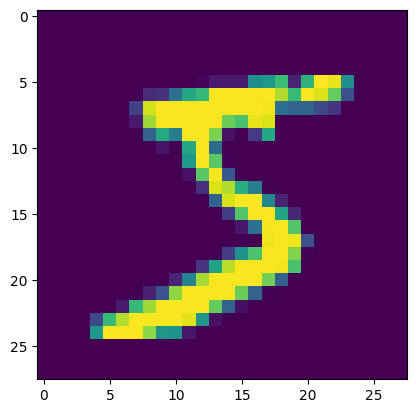

In [3]:
plt.imshow(X[0].reshape(28, 28))

In [26]:
n_training_samples = 7291
n_test_samples = 2007

n_training_samples_for_class = n_training_samples // 10
n_test_samples_for_class = n_test_samples // 10

n_training_samples_for_class, n_test_samples_for_class

(729, 200)

In [31]:
X = X.reshape(-1, 28, 28, 1)

In [32]:
classes = np.unique(y)
n_samples_for_class = n_training_samples_for_class + n_test_samples_for_class

X_train, y_train = [], []
X_test , y_test = [], []

for i, cls in enumerate(classes):
    inxs = np.where(y == cls)[0]
    inxs = np.random.choice(inxs, n_samples_for_class, False)

    train_i, test_i = inxs[:n_training_samples_for_class], inxs[n_training_samples_for_class:]

    X_train.extend(X[train_i])
    y_train.extend(y[train_i])

    X_test.extend(X[test_i])
    y_test.extend(y[test_i])

X_train = np.array(X_train)
y_train = np.array(y_train)

shuffle_inxs = np.random.permutation(len(X_train))

X_train = X_train[shuffle_inxs]
y_train = y_train[shuffle_inxs]

In [35]:
X_test = np.array(X_test)
y_test = np.array(y_test)

In [36]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder()
y_train_mse = encoder.fit_transform(y_train.reshape(-1, 1))
y_test_mse = encoder.transform(y_test.reshape(-1, 1))

In [20]:
X_train.shape

(7290, 784)

In [22]:
X_train = X_train.reshape(-1, 28, 28, 1)

In [ ]:
class H2(tf.keras.layers.Layer):
    def __init__(self, filters, kernel_size=5, kernel_size_depth=8, **kwargs):
        super().__init__(**kwargs)

        self.filters = filters
        self.kernel_size = kernel_size
        self.kernel_size_depth = kernel_size_depth

        self.convs = []
        for _ in range(filters):
            initializer = tf.keras.initializers.VarianceScaling(2.4, 
                                                                mode='fan_in',
                                                                distribution='uniform')
            
            self.convs.append(tf.keras.layers.Conv2D(1, 
                                                     padding='same',
                                                     kernel_size=kernel_size,
                                                     activation='tanh',
                                                     kernel_initializer=initializer))
            
        self.concat = tf.keras.layers.Concatenate(axis=-1)

    def call(self, input):
        C_in = input.shape[-1]
        inxs = tf.range(C_in)

        maps = []

        for i in range(len(self.convs)):
            maps_inxs = tf.range(i, i + self.kernel_size_depth) % C_in
            conv_inp = tf.gather(input, maps_inxs, axis=-1)
            maps.append(self.convs[i](conv_inp))

        return self.concat(maps)

In [ ]:
preprocessing = tf.keras.models.Sequential([
    tf.keras.layers.Resizing(16, 16),
    tf.keras.layers.Rescaling(1. / 127.5, offset=-1)
])

model = tf.keras.models.Sequential([
    tf.keras.layers.Input([16, 16, 1]),

    tf.keras.layers.Conv2D(12, kernel_size=5, strides=2, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(12, kernel_size=5, strides=2, padding='same', activation='relu', kernel_initializer='he_normal'),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(30, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dense(10, activation='softmax')
])

2026-02-02 18:35:12.600997: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
